In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from cat_simulator import CatSimulator
from cat_simulator import *

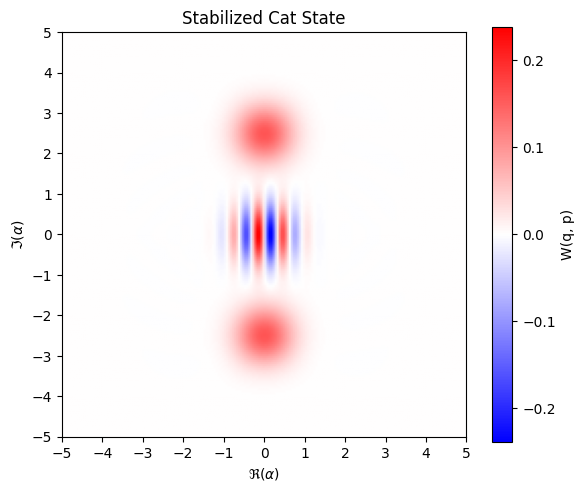

In [4]:
memory_N = 20
alpha_stab = 2.5 * 1j
kappa_2photon = 2
initial_state = (qt.fock(memory_N, 0) - qt.fock(memory_N, 1)).unit()
# initial_state = qt.fock(memory_N, 0)
cat = CatSimulator(memory_N)
cat.simulate_stabalization(T = 2, dt = 0.01, alpha_stab=alpha_stab, kappa_2photon=kappa_2photon, kappa_1photon_memory=0, initial_state=initial_state)

plot_wigner(cat.get_current_state(), "Stabilized Cat State", 5, 200)

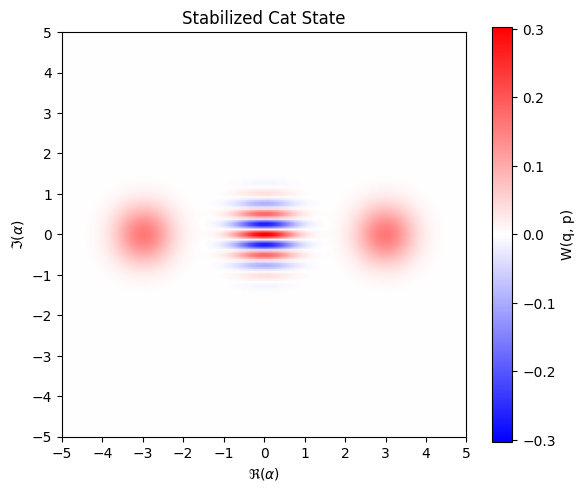

In [82]:
memory_N = 30
alpha_stab = 0
kappa_2photon = 2
# initial_state = (qt.fock(memory_N, 0) - qt.fock(memory_N, 1)).unit()
initial_state = qt.fock(memory_N, 0)
cat = CatSimulator(memory_N)
cat.simulate_stabalization(T = 10, dt = 0.01, alpha_stab=alpha_stab, kappa_2photon=kappa_2photon, kappa_1photon_memory=0, initial_state=initial_state, epsilon_squeezing_memory = -9j)

plot_wigner(cat.get_current_state(), "Stabilized Cat State", 5, 200)

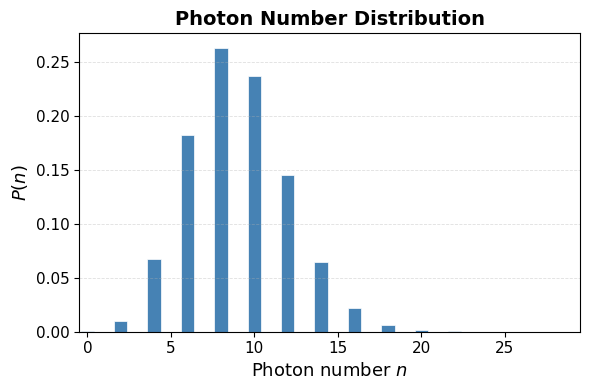

In [43]:
plot_photon_number(cat.get_current_state(), "Photon Number Distribution")

# 2

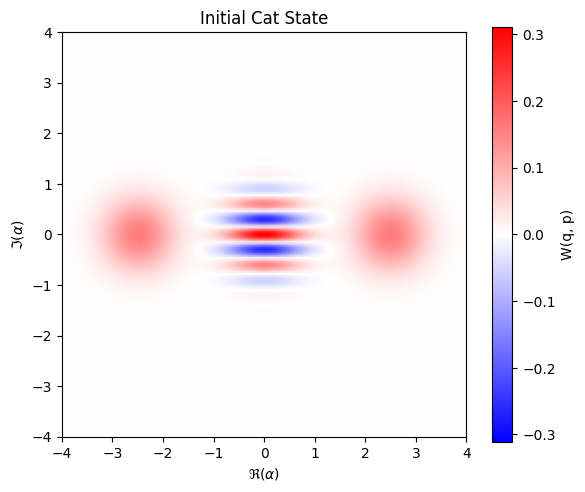

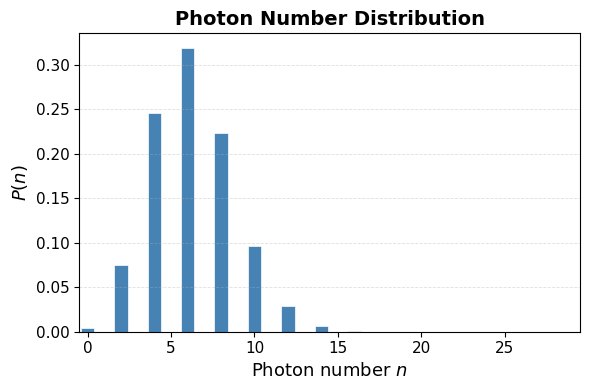

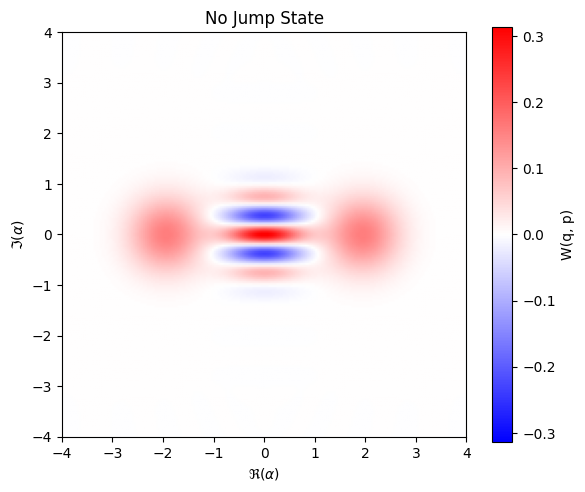

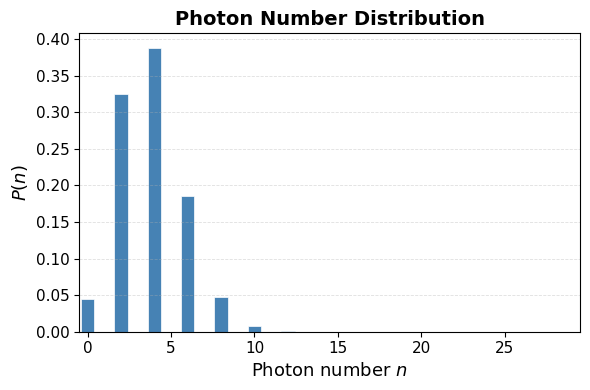

In [44]:
initial_state = (qt.coherent(memory_N, 2.5) + qt.coherent(memory_N, -2.5)).unit()
plot_wigner(initial_state, "Initial Cat State", 4, 200)
plot_photon_number(initial_state, "Photon Number Distribution")
n = qt.num(memory_N)
no_jump_state = ((-1*(0.5)/2 * n).expm() * initial_state).unit()
plot_wigner(no_jump_state, "No Jump State", 4, 200)
plot_photon_number(no_jump_state, "Photon Number Distribution")

# over driving buffer

In [76]:
memory_N = 20
cat = CatSimulator(memory_N)
cat.simulate_stabalization(T = 10, dt = 0.01, g_2 = 0, kappa_1photon_memory = 1, epsilon_drive_memory= - 1.4)

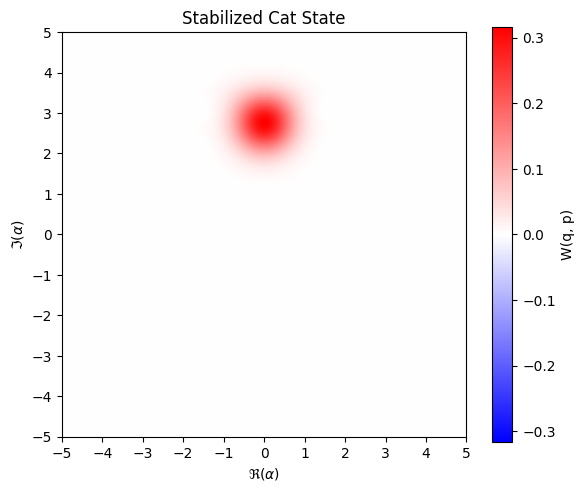

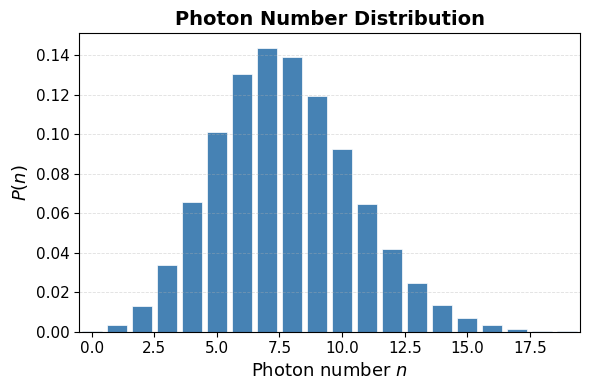

In [77]:
plot_wigner(cat.get_current_state(), "Stabilized Cat State", 5, 200)
plot_photon_number(cat.get_current_state(), "Photon Number Distribution")

In [80]:
memory_N = 40
buffer_N = 15
cat = CatSimulator(memory_N, buffer_N)
cat.simulate_stabalization(T = 15, dt = 0.01, g_2 = 0.1, kappa_1photon_buffer = 1, epsilon_drive_buffer = -1.4) # get squeezing here

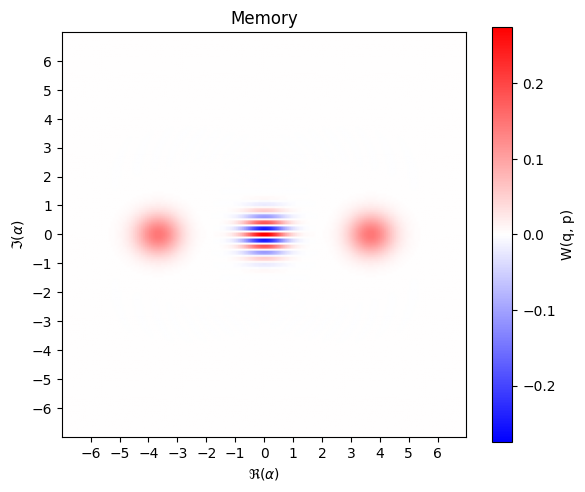

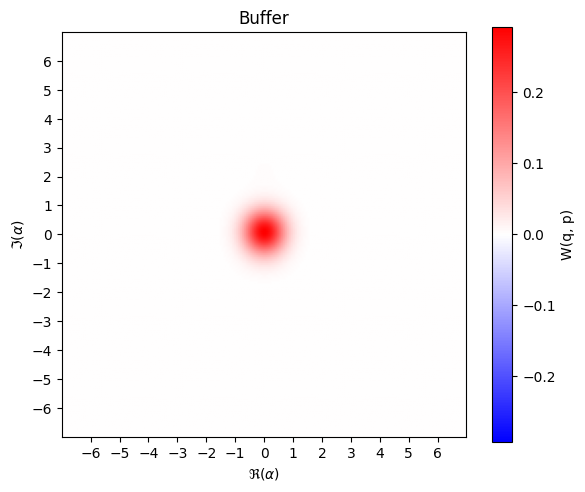

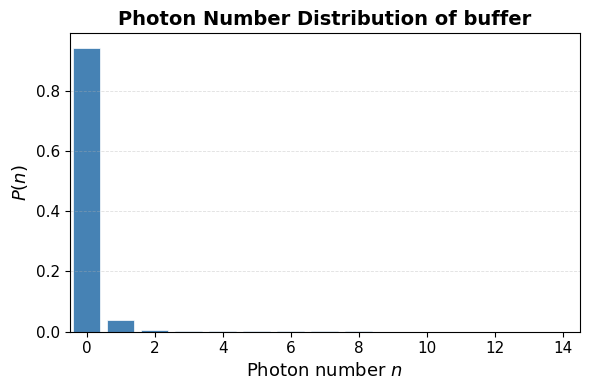

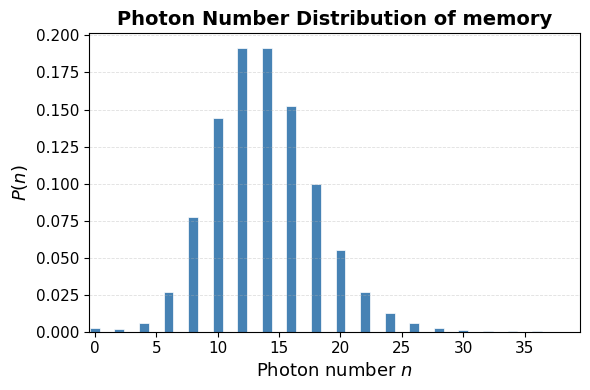

In [81]:
plot_wigner( qt.ptrace(cat.get_current_state(), 0), "Memory", 7, 200)
plot_wigner( qt.ptrace(cat.get_current_state(), 1), "Buffer", 7, 200)
plot_photon_number( qt.ptrace(cat.get_current_state(), 1), "Photon Number Distribution of buffer")
plot_photon_number( qt.ptrace(cat.get_current_state(), 0), "Photon Number Distribution of memory")

# adiabatic regime

In [30]:
memory_N = 20
buffer_N = 3
cat = CatSimulator(memory_N, buffer_N)
cat.simulate_stabalization(T = 20, dt = 0.01, g_2 = 1, kappa_1photon_buffer = 5, epsilon_drive_buffer = - 2.5**2) # get squeezing here

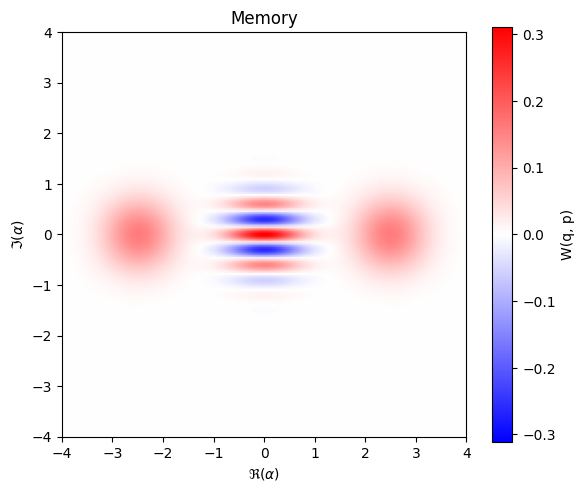

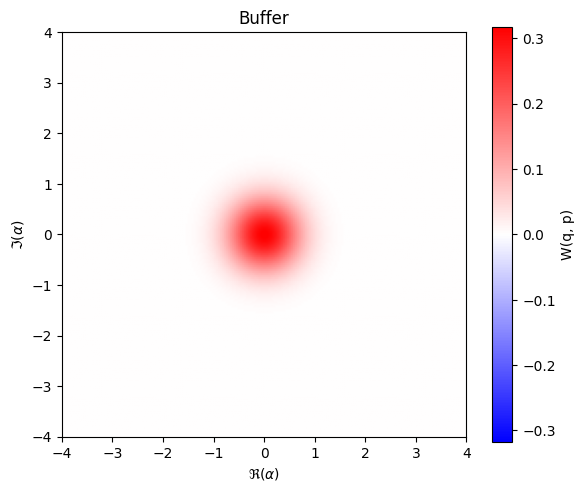

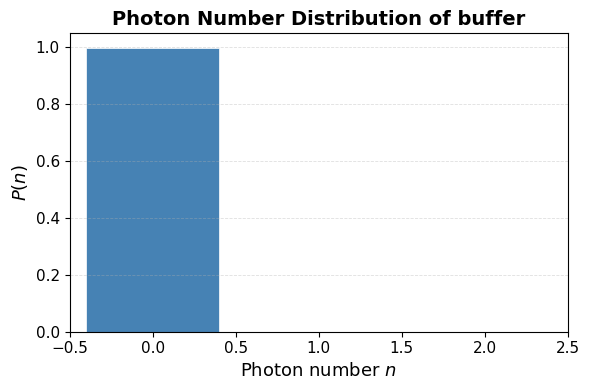

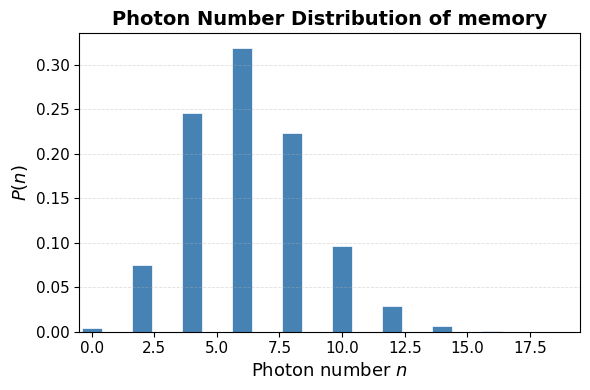

In [31]:
plot_wigner( qt.ptrace(cat.get_current_state(), 0), "Memory", 4, 200)
plot_wigner( qt.ptrace(cat.get_current_state(), 1), "Buffer", 4, 200)
plot_photon_number( qt.ptrace(cat.get_current_state(), 1), "Photon Number Distribution of buffer")
plot_photon_number( qt.ptrace(cat.get_current_state(), 0), "Photon Number Distribution of memory")

In [32]:
print("average buffer photon number: ", qt.expect(qt.num(buffer_N), qt.ptrace(cat.get_current_state(), 1)))

average buffer photon number:  0.00022295718890705802
